# sPHENIX Central-Membrane Laser Lamination Comparison

This notebook compares central-membrane laser patterns produced with different `PHGarfield` configurations.

It supports:
- one ROOT file at a time;
- South/North side-by-side;
- `raw` vs `garfield`;
- overlays of two or more correction configurations;
- automatic PDF saving;
- sector/window-style `phi-R` panels;
- later addition of no-beam and field-off/no-beam reference samples.

Default display ranges follow the supplied reference figures:
- `R = 30–80 cm`
- `phi = 0–2π`
- `x,y = -85–85 cm`

Expected histogram names include:
`hLaserCluster_raw_negz`, `hLaserCluster_garfield_negz`,
`hLaserCluster_raw_posz`, `hLaserCluster_garfield_posz`.

In [1]:
import ROOT as root
import os
import math
from pathlib import Path

root.gStyle.SetOptStat(0)
root.gStyle.SetTitleBorderSize(0)
root.gStyle.SetPadTickX(1)
root.gStyle.SetPadTickY(1)

ROOT_KEEPALIVE = []

INPUT_DIR = Path("input")
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PDF = True
SAVE_PNG = False

R_MIN = 30.0
R_MAX = 80.0
PHI_MIN = 0.0
PHI_MAX = 2.0 * math.pi
XY_MIN = -85.0
XY_MAX = 85.0

MIN_BIN_CONTENT = 0.0
DEFAULT_MARKER_SIZE = 0.40

SIDE_INFO = {
    "South": {"suffix": "negz"},
    "North": {"suffix": "posz"},
}

print("Input directory :", INPUT_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Welcome to JupyROOT 6.30/06
Input directory : /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/cm/input
Output directory: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/cm/plots


## Input files
Edit this dictionary as more runs are produced.

In [23]:
FILE_CONFIGS = {
    "no beam no field 78242 IFC": "LaserClusterGarfieldPropagation-00078242_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot.root",#00078242_zerofield_radialdriftcomponent 00078242_nobeam_nofield_1p8_0_0p0_m120_rot 00078242_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot
    "no beam with field 83319 IFC": "LaserClusterGarfieldPropagation-00083319_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot.root",#00083319_nobeam_field_1p8_0_0p0_m120_rot 00083319_ifc_nobeam_field_1p8_0_0p0_m120_rot 00083319_ifc_nm111_nobeam_field_1p8_0_0p0_m120_rot
    "no beam with field 75073": "LaserClusterGarfieldPropagation-00075073_nobeam_field_1p8_0_0p0_m120_rot.root",# 00083319_nobeam_field_1p8_0_0p0_m120_rot 00075073_nobeam_field_1p8_0_0p0_m120_rot 00083319_nobeam1
    "Static 2D": "LaserClusterGarfieldPropagation-00079513_test2d_1p23_1p0_1p6.root",
    "3D": "LaserClusterGarfieldPropagation-00079513_test3d_1p8_0p9_1p5.root",
    "3D + frames": "LaserClusterGarfieldPropagation-00079513_iofc_nm111_1p8_1p5_1p5_m120_rot.root",#00079513_test3d_1p8_0p9_1p5_m120_rot1 00079513_ifc_1p8_1p5_1p5_m120_rot 00079513_ifc_nm111_1p8_1p5_1p5_m120_rot 00079513_iofc_nm111_1p8_1p5_1p5_m120_rot 
    "Lower Lum 79513": "LaserClusterGarfieldPropagation-00079513_iofc_nm111_1p8_2p25_2p25_m120_rot.root",#00079513_iofc_nm111_12p0_1p5_1p5_m120_rot 00079513_iofc_nm111_1p8_2p25_2p25_m120_rot 00079516_test3d_1p8_0p9_1p6_m120_rot
    "Higher Lum 79507": "LaserClusterGarfieldPropagation-00079507_iofc_nm111_1p0_2p25_2p25_m120_rot.root",#00079507_iofc_nm111_1p0_2p25_2p25_m120_rot 00079513_iofc_nm111_12p0_1p5_1p5_m120_rot
}
FILE_CONFIGS = {label: INPUT_DIR / name for label, name in FILE_CONFIGS.items()}

for label, filename in FILE_CONFIGS.items():
    print(f"{label:24s} : {filename}   [{'OK' if filename.exists() else 'MISSING'}]")

no beam no field 78242 IFC : input/LaserClusterGarfieldPropagation-00078242_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot.root   [OK]
no beam with field 83319 IFC : input/LaserClusterGarfieldPropagation-00083319_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot.root   [OK]
no beam with field 75073 : input/LaserClusterGarfieldPropagation-00075073_nobeam_field_1p8_0_0p0_m120_rot.root   [OK]
Static 2D                : input/LaserClusterGarfieldPropagation-00079513_test2d_1p23_1p0_1p6.root   [OK]
3D                       : input/LaserClusterGarfieldPropagation-00079513_test3d_1p8_0p9_1p5.root   [OK]
3D + frames              : input/LaserClusterGarfieldPropagation-00079513_iofc_nm111_1p8_1p5_1p5_m120_rot.root   [OK]
Lower Lum 79513          : input/LaserClusterGarfieldPropagation-00079513_iofc_nm111_1p8_2p25_2p25_m120_rot.root   [OK]
Higher Lum 79507         : input/LaserClusterGarfieldPropagation-00079507_iofc_nm111_1p0_2p25_2p25_m120_rot.root   [OK]


In [24]:
print("ROOT files found in input/:")
for f in sorted(INPUT_DIR.glob("LaserClusterGarfieldPropagation*.root")):
    print(" ", f.name)

ROOT files found in input/:
  LaserClusterGarfieldPropagation-00075073.root
  LaserClusterGarfieldPropagation-00075073_nobeam_field_1p8_0_0p0_m120_rot.root
  LaserClusterGarfieldPropagation-00075073_nobeam_field_1p8_0_0p6_m120_rot.root
  LaserClusterGarfieldPropagation-00075073_radialdriftcomponent.root
  LaserClusterGarfieldPropagation-00075073_zerofield.root
  LaserClusterGarfieldPropagation-00078242_iofc_nm111_nobeam_field_1p8_0_0p0_m120_rot.root
  LaserClusterGarfieldPropagation-00078242_nobeam_nofield.root
  LaserClusterGarfieldPropagation-00078242_nobeam_nofield_1p8_0_0p0_m120_rot.root
  LaserClusterGarfieldPropagation-00078242_zerofield_radialdriftcomponent.root
  LaserClusterGarfieldPropagation-00079507_iofc_nm111_1p0_2p25_2p25_m120_rot.root
  LaserClusterGarfieldPropagation-00079507_iofc_nm111_1p8_1p5_1p5_m120_rot.root
  LaserClusterGarfieldPropagation-00079507_iofc_nm111_s1p8_1p5_1p5_m120_rot.root
  LaserClusterGarfieldPropagation-00079507_test3d_1p8_0p9_1p6_m120_rot.root
  L

## ROOT helpers

In [4]:
def _unique_name(prefix):
    return f"{prefix}_{len(ROOT_KEEPALIVE)}"

def open_root_file(filename):
    f = root.TFile.Open(str(filename))
    if not f or f.IsZombie():
        raise RuntimeError(f"Cannot open ROOT file: {filename}")
    ROOT_KEEPALIVE.append(f)
    return f

def get_laser_hist(filename, side="South", kind="garfield"):
    suffix = SIDE_INFO[side]["suffix"]
    hname = f"hLaserCluster_{kind}_{suffix}"
    f = open_root_file(filename)
    h = f.Get(hname)
    if not h:
        raise RuntimeError(f"Histogram '{hname}' not found in {filename}")
    hcopy = h.Clone(_unique_name(hname))
    hcopy.SetDirectory(0)
    ROOT_KEEPALIVE.append(hcopy)
    return hcopy

def list_histograms(filename, contains="LaserCluster"):
    f = open_root_file(filename)
    names = [k.GetName() for k in f.GetListOfKeys()]
    return [x for x in names if contains in x]

## Convert occupied `(phi,R)` bins to graphs

In [5]:
def hist_to_phi_r_graph(hist, min_content=MIN_BIN_CONTENT):
    pts = []
    for ix in range(1, hist.GetNbinsX()+1):
        phi = hist.GetXaxis().GetBinCenter(ix) % (2.0*math.pi)
        for iy in range(1, hist.GetNbinsY()+1):
            c = hist.GetBinContent(ix, iy)
            if c <= min_content:
                continue
            r = hist.GetYaxis().GetBinCenter(iy)
            if R_MIN <= r <= R_MAX:
                pts.append((phi, r))

    g = root.TGraph(len(pts))
    g.SetName(_unique_name("g_phir"))
    for i,(x,y) in enumerate(pts):
        g.SetPoint(i,x,y)
    ROOT_KEEPALIVE.append(g)
    return g

def hist_to_xy_graph(hist, min_content=MIN_BIN_CONTENT):
    pts = []
    for ix in range(1, hist.GetNbinsX()+1):
        phi = hist.GetXaxis().GetBinCenter(ix)
        for iy in range(1, hist.GetNbinsY()+1):
            c = hist.GetBinContent(ix, iy)
            if c <= min_content:
                continue
            r = hist.GetYaxis().GetBinCenter(iy)
            if R_MIN <= r <= R_MAX:
                pts.append((r*math.cos(phi), r*math.sin(phi)))

    g = root.TGraph(len(pts))
    g.SetName(_unique_name("g_xy"))
    for i,(x,y) in enumerate(pts):
        g.SetPoint(i,x,y)
    ROOT_KEEPALIVE.append(g)
    return g

## Common drawing helpers

In [6]:
def draw_phi_r_frame(title=""):
    h = root.TH2F(_unique_name("frame_phir"), title,
                  100, PHI_MIN, PHI_MAX, 100, R_MIN, R_MAX)
    h.SetDirectory(0)
    h.GetXaxis().SetTitle("#phi [rad]")
    h.GetYaxis().SetTitle("R [cm]")
    h.GetXaxis().SetTitleSize(0.050)
    h.GetYaxis().SetTitleSize(0.050)
    h.GetXaxis().SetLabelSize(0.042)
    h.GetYaxis().SetLabelSize(0.042)
    h.Draw()
    ROOT_KEEPALIVE.append(h)
    return h

def draw_xy_frame(title=""):
    h = root.TH2F(_unique_name("frame_xy"), title,
                  100, XY_MIN, XY_MAX, 100, XY_MIN, XY_MAX)
    h.SetDirectory(0)
    h.GetXaxis().SetTitle("x [cm]")
    h.GetYaxis().SetTitle("y [cm]")
    h.GetXaxis().SetTitleSize(0.050)
    h.GetYaxis().SetTitleSize(0.050)
    h.GetXaxis().SetLabelSize(0.042)
    h.GetYaxis().SetLabelSize(0.042)
    h.Draw()
    ROOT_KEEPALIVE.append(h)
    return h

def draw_side_label(side, x=0.72, y=0.88):
    t = root.TLatex()
    t.SetNDC()
    t.SetTextFont(62)
    t.SetTextSize(0.062)
    t.DrawLatex(x, y, side)
    ROOT_KEEPALIVE.append(t)
    return t

def safe_filename(text):
    s = str(text)
    for ch in [" ", "+", "/", "\\", ":", ";", ",", "(", ")", "[", "]"]:
        s = s.replace(ch, "_")
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

def save_canvas(c, stem):
    stem = safe_filename(stem)
    if SAVE_PDF:
        c.SaveAs(str(OUTPUT_DIR / f"{stem}.pdf"))
    if SAVE_PNG:
        c.SaveAs(str(OUTPUT_DIR / f"{stem}.png"))

def make_legend(x1=0.52, y1=0.68, x2=0.89, y2=0.88, text_size=0.035):
    leg = root.TLegend(x1,y1,x2,y2)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextSize(text_size)
    ROOT_KEEPALIVE.append(leg)
    return leg

## One file: South + North in `phi-R`

In [7]:
def plot_single_phi_r(label, filename=None, kind="garfield",
                      min_content=MIN_BIN_CONTENT, save=True):
    if filename is None:
        filename = FILE_CONFIGS[label]

    c = root.TCanvas(_unique_name("c_single_phir"), "", 1500, 650)
    c.Divide(2,1)

    for ipad, side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.12)
        root.gPad.SetBottomMargin(0.12)

        h = get_laser_hist(filename, side=side, kind=kind)
        g = hist_to_phi_r_graph(h, min_content)

        draw_phi_r_frame(f"{label} - {side}")
        g.SetMarkerStyle(20)
        g.SetMarkerSize(DEFAULT_MARKER_SIZE)
        g.Draw("P SAME")
        draw_side_label(side)

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, f"phiR_{label}_{kind}")
    return c

# Example:
#plot_single_phi_r("3D + frames")

## One file: South + North in `x-y`

In [8]:
def plot_single_xy(label, filename=None, kind="garfield",
                   min_content=MIN_BIN_CONTENT, save=True):
    if filename is None:
        filename = FILE_CONFIGS[label]

    c = root.TCanvas(_unique_name("c_single_xy"), "", 1500, 700)
    c.Divide(2,1)

    for ipad, side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.13)
        root.gPad.SetBottomMargin(0.12)

        h = get_laser_hist(filename, side=side, kind=kind)
        g = hist_to_xy_graph(h, min_content)

        draw_xy_frame("")
        g.SetMarkerStyle(20)
        g.SetMarkerSize(DEFAULT_MARKER_SIZE)
        g.Draw("P SAME")
        draw_side_label(side)

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, f"xy_{label}_{kind}")
    return c

# Example:
#plot_single_xy("3D + frames")

## Overlay several configurations

In [9]:
COMPARE_COLORS = [
    root.kBlue+1,
    root.kRed+1,
    root.kGreen+2,
    root.kMagenta+1,
    root.kOrange+7,
    root.kCyan+2,
    root.kBlack,
]
COMPARE_MARKERS = [20,20,21,25,22,26,33]

In [10]:
def compare_xy(labels, kind="garfield", min_content=MIN_BIN_CONTENT,
               output_name="comparison_xy", save=True):
    c = root.TCanvas(_unique_name("c_compare_xy"), "", 1600, 720)
    c.Divide(2,1)

    for ipad, side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.13)
        root.gPad.SetBottomMargin(0.12)
        root.gPad.SetRightMargin(0.01)
        root.gPad.SetTopMargin(0.01)
        draw_xy_frame("")

        gs = []
        for i,label in enumerate(labels):
            h = get_laser_hist(FILE_CONFIGS[label], side=side, kind=kind)
            g = hist_to_xy_graph(h, min_content)
            color = COMPARE_COLORS[i % len(COMPARE_COLORS)]
            marker = COMPARE_MARKERS[i % len(COMPARE_MARKERS)]
            g.SetMarkerStyle(marker)
            if i == 0:
                g.SetLineColorAlpha(color,1)
                g.SetMarkerColorAlpha(color,1)
                g.SetMarkerSize(0.52)
            else:
                g.SetMarkerColorAlpha(color,0.5)
                g.SetLineColorAlpha(color,0.5)
                g.SetMarkerSize(0.32)
            g.Draw("P SAME")
            gs.append(g)

        draw_side_label(side,0.22,0.92)

        if ipad == 2:
            leg = make_legend(0.65, 0.90, 0.98, 0.98, text_size=0.045)
            for label,g in zip(labels,gs):
                leg.AddEntry(g,label,"p")
            leg.Draw()

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, output_name)
    return c


def compare_phi_r(labels, kind="garfield", min_content=MIN_BIN_CONTENT,
                  output_name="comparison_phiR", save=True):
    c = root.TCanvas(_unique_name("c_compare_phir"), "", 1600, 700)
    c.Divide(2,1)

    for ipad, side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.12)
        root.gPad.SetBottomMargin(0.12)
        root.gPad.SetRightMargin(0.01)
        root.gPad.SetTopMargin(0.01)
        draw_phi_r_frame("")

        gs = []
        for i,label in enumerate(labels):
            h = get_laser_hist(FILE_CONFIGS[label], side=side, kind=kind)
            g = hist_to_phi_r_graph(h, min_content)
            color = COMPARE_COLORS[i % len(COMPARE_COLORS)]
            marker = COMPARE_MARKERS[i % len(COMPARE_MARKERS)]
            if i == 0:
                g.SetLineColorAlpha(color,1)
                g.SetMarkerSize(0.48)
            else:
                g.SetMarkerColorAlpha(color,0.5)
                g.SetMarkerSize(0.38)
            g.SetLineColor(color)
            g.SetMarkerStyle(marker)
            g.Draw("P SAME")
            gs.append(g)

        draw_side_label(side,0.22,0.92)

        if ipad == 2:
            leg = make_legend(0.65, 0.90, 0.98, 0.98, text_size=0.045)
            for label,g in zip(labels,gs):
                leg.AddEntry(g,label,"p")
            leg.Draw()

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, output_name)
    return c


def compare_two_xy(reference_label, corrected_label, output_name=None, **kwargs):
    if output_name is None:
        output_name = f"compare_{reference_label}_vs_{corrected_label}_xy"
    return compare_xy([reference_label, corrected_label],
                      output_name=output_name, **kwargs)

In [11]:
#Suggested progression:
if False:
    compare_xy(
        ["no beam no field", "3D + frames"],
        output_name="79513_correction_progression_xy",
    )
    compare_phi_r(
        ["no beam no field", "3D + frames"],
        output_name="79513_correction_progression_phiR",
    )
if False:
    compare_xy(
        ["no beam no field", "Static"],
        output_name="75073_correction_progression_xy",
    )
    compare_phi_r(
        ["no beam no field", "Static"],
        output_name="75073_correction_progression_phiR",
    )

## Raw vs PHGarfield within the same file

In [12]:
def compare_raw_garfield_xy(label, min_content=MIN_BIN_CONTENT, save=True):
    filename = FILE_CONFIGS[label]
    c = root.TCanvas(_unique_name("c_raw_garfield_xy"), "", 1600, 700)
    c.Divide(2,1)

    for ipad,side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.13)
        root.gPad.SetBottomMargin(0.12)
        draw_xy_frame("")

        hraw = get_laser_hist(filename, side=side, kind="raw")
        hgar = get_laser_hist(filename, side=side, kind="garfield")
        graw = hist_to_xy_graph(hraw, min_content)
        ggar = hist_to_xy_graph(hgar, min_content)

        graw.SetMarkerColor(root.kBlue+1)
        graw.SetMarkerStyle(20)
        graw.SetMarkerSize(0.38)

        ggar.SetMarkerColor(root.kRed+1)
        ggar.SetMarkerStyle(24)
        ggar.SetMarkerSize(0.38)

        graw.Draw("P SAME")
        ggar.Draw("P SAME")
        draw_side_label(side)

        if ipad == 2:
            leg = make_legend(0.56,0.73,0.89,0.88,0.038)
            leg.AddEntry(graw,"Raw","p")
            leg.AddEntry(ggar,"PHGarfield","p")
            leg.Draw()

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, f"raw_vs_garfield_{label}_xy")
    return c


def compare_raw_garfield_phi_r(label, min_content=MIN_BIN_CONTENT, save=True):
    filename = FILE_CONFIGS[label]
    c = root.TCanvas(_unique_name("c_raw_garfield_phir"), "", 1600, 700)
    c.Divide(2,1)

    for ipad,side in enumerate(["South","North"], start=1):
        c.cd(ipad)
        root.gPad.SetLeftMargin(0.12)
        root.gPad.SetBottomMargin(0.12)
        draw_phi_r_frame("")

        hraw = get_laser_hist(filename, side=side, kind="raw")
        hgar = get_laser_hist(filename, side=side, kind="garfield")
        graw = hist_to_phi_r_graph(hraw, min_content)
        ggar = hist_to_phi_r_graph(hgar, min_content)

        graw.SetMarkerColor(root.kBlue+1)
        graw.SetMarkerStyle(20)
        graw.SetMarkerSize(0.35)

        ggar.SetMarkerColor(root.kRed+1)
        ggar.SetMarkerStyle(24)
        ggar.SetMarkerSize(0.35)

        graw.Draw("P SAME")
        ggar.Draw("P SAME")
        draw_side_label(side)

        if ipad == 2:
            leg = make_legend(0.56,0.73,0.89,0.88,0.038)
            leg.AddEntry(graw,"Raw","p")
            leg.AddEntry(ggar,"PHGarfield","p")
            leg.Draw()

    c.Update()
    ROOT_KEEPALIVE.append(c)
    if save:
        save_canvas(c, f"raw_vs_garfield_{label}_phiR")
    return c

# Example:
#compare_raw_garfield_xy("3D + frames")

## Sector/window-style `phi-R` plot

This reproduces the narrow-window multi-panel style of the supplied reference figure.
The default is 18 evenly-spaced windows. Adjust the number and half-width if needed.

In [13]:
# ============================================================
# Sector/window-style phi-R plots
#
# South:
#   The regular 18-window construction already reproduces
#   the original South plot well.
#
# North:
#   The same pattern is shifted by about +0.20 rad in phi.
# ============================================================

N_PHI_WINDOWS = 18
PHI_WINDOW_HALF_WIDTH = 0.05

# Approximate side-dependent offset from the original plots
PHI_WINDOW_OFFSET = {
    "South": 0.00,
    "North": 0.175,
}


def make_phi_windows(
    side="South",
    n_windows=N_PHI_WINDOWS,
    half_width=PHI_WINDOW_HALF_WIDTH,
):
    """
    Build equally spaced phi windows around 2pi.

    South uses the nominal positions.
    North is shifted by approximately +0.20 rad,
    matching the original North lamination plots.
    """

    if side not in PHI_WINDOW_OFFSET:
        raise ValueError(f"Unknown side: {side}")

    spacing = 2.0 * math.pi / n_windows
    offset = PHI_WINDOW_OFFSET[side]

    centers = [
        (i + 0.5) * spacing + offset
        for i in range(n_windows)
    ]

    return [
        (center - half_width, center + half_width)
        for center in centers
    ]


def plot_sector_windows(
    label,
    side="North",
    kind="garfield",
    n_windows=N_PHI_WINDOWS,
    half_width=PHI_WINDOW_HALF_WIDTH,
    min_content=MIN_BIN_CONTENT,
    ncols=6,
    save=True,
):
    filename = FILE_CONFIGS[label]

    h = get_laser_hist(
        filename,
        side=side,
        kind=kind,
    )

    # Side-dependent windows
    windows = make_phi_windows(
        side=side,
        n_windows=n_windows,
        half_width=half_width,
    )

    nrows = math.ceil(n_windows / ncols)

    c = root.TCanvas(
        _unique_name("c_sector_windows"),
        "",
        1800,
        350 * nrows,
    )

    c.Divide(
        ncols,
        nrows,
        0.001,
        0.001,
    )

    # ========================================================
    # Loop over phi windows
    # ========================================================

    for iwin, (phi_lo, phi_hi) in enumerate(windows):

        c.cd(iwin + 1)

        root.gPad.SetLeftMargin(0.16)
        root.gPad.SetRightMargin(0.04)
        root.gPad.SetBottomMargin(0.17)
        root.gPad.SetTopMargin(0.08)

        pts = []

        # ----------------------------------------------------
        # Select occupied histogram bins inside this phi window
        # ----------------------------------------------------

        for ix in range(1, h.GetNbinsX() + 1):

            phi = (
                h.GetXaxis().GetBinCenter(ix)
                % (2.0 * math.pi)
            )

            # Handle windows crossing 0 or 2pi
            if phi_lo < 0.0:

                inside = (
                    phi >= phi_lo + 2.0 * math.pi
                    or
                    phi <= phi_hi
                )

            elif phi_hi >= 2.0 * math.pi:

                inside = (
                    phi >= phi_lo
                    or
                    phi <= phi_hi - 2.0 * math.pi
                )

            else:

                inside = (
                    phi_lo <= phi <= phi_hi
                )

            if not inside:
                continue

            # ------------------------------------------------
            # R bins
            # ------------------------------------------------

            for iy in range(1, h.GetNbinsY() + 1):

                content = h.GetBinContent(ix, iy)

                if content <= min_content:
                    continue

                r = h.GetYaxis().GetBinCenter(iy)

                if not (R_MIN <= r <= R_MAX):
                    continue

                # Shift wrapped points into the displayed
                # coordinate interval.
                x = phi

                if phi_lo < 0.0 and phi > math.pi:
                    x -= 2.0 * math.pi

                if phi_hi >= 2.0 * math.pi and phi < math.pi:
                    x += 2.0 * math.pi

                pts.append((x, r))

        # ====================================================
        # Frame
        # ====================================================

        frame = root.TH2F(
            _unique_name("frame_sector"),
            "",
            100,
            phi_lo,
            phi_hi,
            100,
            R_MIN,
            R_MAX,
        )

        frame.SetDirectory(0)

        frame.GetXaxis().SetTitle("#phi [rad]")
        frame.GetYaxis().SetTitle("R [cm]")

        frame.GetXaxis().SetTitleSize(0.065)
        frame.GetYaxis().SetTitleSize(0.065)

        frame.GetXaxis().SetLabelSize(0.052)
        frame.GetYaxis().SetLabelSize(0.052)

        frame.Draw()

        ROOT_KEEPALIVE.append(frame)

        # ====================================================
        # Points
        # ====================================================

        g = root.TGraph(len(pts))
        g.SetName(_unique_name("g_sector"))

        for ip, (x, y) in enumerate(pts):
            g.SetPoint(ip, x, y)

        g.SetMarkerStyle(20)
        g.SetMarkerSize(0.25)

        g.Draw("P SAME")

        ROOT_KEEPALIVE.append(g)

    # ========================================================
    # Canvas title
    # ========================================================

    c.cd()

    title = root.TLatex()

    title.SetNDC()
    title.SetTextAlign(22)
    title.SetTextFont(62)
    title.SetTextSize(0.025)

    title.DrawLatex(
        0.5,
        0.995,
        f"{label}   {side}",
    )

    ROOT_KEEPALIVE.append(title)

    c.Update()
    ROOT_KEEPALIVE.append(c)

    if save:
        save_canvas(
            c,
            f"sector_windows_{label}_{side}_{kind}",
        )

    return c


# ============================================================
# Examples
# ============================================================
if False:
    plot_sector_windows(
        "no beam no field",
        side="North",
    )
    
    plot_sector_windows(
        "no beam no field",
        side="South",
    )
    
    plot_sector_windows(
        "Zero field false",
        side="North",
    )
    
    plot_sector_windows(
        "Zero field false",
        side="South",
    )
    
    plot_sector_windows(
        "Static",
        side="North",
    )
    
    plot_sector_windows(
        "Static",
        side="South",
    )
    plot_sector_windows(
        "Static 2D",
        side="North",
    )
    
    plot_sector_windows(
        "Static 2D",
        side="South",
    )
    
    plot_sector_windows(
        "3D + frames",
        side="North",
    )
    
    plot_sector_windows(
        "3D + frames",
        side="South",
    )

In [14]:
# ============================================================
# Compare several configurations in the same sector windows
# ============================================================

def compare_sector_windows(
    labels,
    side="North",
    kind="garfield",
    n_windows=N_PHI_WINDOWS,
    half_width=PHI_WINDOW_HALF_WIDTH,
    min_content=MIN_BIN_CONTENT,
    ncols=6,
    save=True,
    output_name=None,
):
    """Overlay several configurations in the same narrow phi windows."""

    histograms = {
        label: get_laser_hist(FILE_CONFIGS[label], side=side, kind=kind)
        for label in labels
    }

    windows = make_phi_windows(side=side, n_windows=n_windows, half_width=half_width)
    nrows = math.ceil(n_windows / ncols)

    c = root.TCanvas(_unique_name("c_compare_sector_windows"), "", 1800, 350 * nrows)
    c.Divide(ncols, nrows, 0.001, 0.001)

    colors = [
        root.kBlue + 1,
        root.kRed + 1,
        root.kGreen + 2,
        root.kMagenta + 1,
        root.kOrange + 7,
        root.kCyan + 2,
    ]

    markers = [20, 24, 21, 25, 22, 26]
    legend_graphs = {}

    for iwin, (phi_lo, phi_hi) in enumerate(windows):
        c.cd(iwin + 1)

        root.gPad.SetLeftMargin(0.16)
        root.gPad.SetRightMargin(0.04)
        root.gPad.SetBottomMargin(0.17)
        root.gPad.SetTopMargin(0.08)

        frame = root.TH2F(
            _unique_name("frame_sector_compare"), "",
            100, phi_lo, phi_hi,
            100, R_MIN, R_MAX,
        )
        frame.SetDirectory(0)
        frame.GetXaxis().SetTitle("#phi [rad]")
        frame.GetYaxis().SetTitle("R [cm]")
        frame.GetXaxis().SetTitleSize(0.065)
        frame.GetYaxis().SetTitleSize(0.065)
        frame.GetXaxis().SetLabelSize(0.052)
        frame.GetYaxis().SetLabelSize(0.052)
        frame.GetXaxis().SetNdivisions(505)
        frame.Draw()
        ROOT_KEEPALIVE.append(frame)

        for ilabel, label in enumerate(labels):
            h = histograms[label]
            pts = []

            for ix in range(1, h.GetNbinsX() + 1):
                phi = h.GetXaxis().GetBinCenter(ix) % (2.0 * math.pi)

                if phi_lo < 0.0:
                    inside = phi >= phi_lo + 2.0 * math.pi or phi <= phi_hi
                elif phi_hi >= 2.0 * math.pi:
                    inside = phi >= phi_lo or phi <= phi_hi - 2.0 * math.pi
                else:
                    inside = phi_lo <= phi <= phi_hi

                if not inside:
                    continue

                for iy in range(1, h.GetNbinsY() + 1):
                    if h.GetBinContent(ix, iy) <= min_content:
                        continue

                    r = h.GetYaxis().GetBinCenter(iy)
                    if not (R_MIN <= r <= R_MAX):
                        continue

                    x = phi

                    if phi_lo < 0.0 and phi > math.pi:
                        x -= 2.0 * math.pi

                    if phi_hi >= 2.0 * math.pi and phi < math.pi:
                        x += 2.0 * math.pi

                    pts.append((x, r))

            g = root.TGraph(len(pts))
            g.SetName(_unique_name(f"g_sector_compare_{safe_filename(label)}"))

            for ip, (x, r) in enumerate(pts):
                g.SetPoint(ip, x, r)

            color = colors[ilabel % len(colors)]
            marker = markers[ilabel % len(markers)]

            # Smaller, semi-transparent markers so overlays stay readable
            g.SetMarkerColorAlpha(color, 0.5)
            g.SetLineColorAlpha(color, 0.5)
            g.SetMarkerStyle(marker)
            g.SetMarkerSize(0.18)
            g.Draw("P SAME")

            ROOT_KEEPALIVE.append(g)

            if label not in legend_graphs:
                legend_graphs[label] = g

    c.cd()

    title = root.TLatex()
    title.SetNDC()
    title.SetTextAlign(22)
    title.SetTextFont(62)
    title.SetTextSize(0.025)
    title.DrawLatex(0.5, 0.99, side)
    ROOT_KEEPALIVE.append(title)

    legend = root.TLegend(0.36, 0.645, 0.64, 0.69)
    legend.SetNColumns(len(labels))
    legend.SetBorderSize(0)
    legend.SetFillStyle(0)
    legend.SetTextSize(0.020)

    for ilabel, label in enumerate(labels):
        g = legend_graphs[label]
        entry = legend.AddEntry(g, label, "p")
        entry.SetTextColor(colors[ilabel % len(colors)])

    legend.Draw()
    ROOT_KEEPALIVE.append(legend)

    c.Update()
    ROOT_KEEPALIVE.append(c)

    if output_name is None:
        joined = "_vs_".join(safe_filename(label) for label in labels)
        output_name = f"sector_compare_{joined}_{side}_{kind}"

    if save:
        save_canvas(c, output_name)

    return c

Info in <TCanvas::Print>: pdf file plots/sector_compare_no_beam_with_field_83319_IFC_vs_3D_frames_North_garfield.pdf has been created
Info in <TCanvas::Print>: pdf file plots/sector_compare_no_beam_with_field_83319_IFC_vs_3D_frames_South_garfield.pdf has been created
Info in <TCanvas::Print>: pdf file plots/sector_compare_Lower_Lum_79513_vs_Higher_Lum_79507_North_garfield.pdf has been created
Info in <TCanvas::Print>: pdf file plots/sector_compare_Lower_Lum_79513_vs_Higher_Lum_79507_South_garfield.pdf has been created


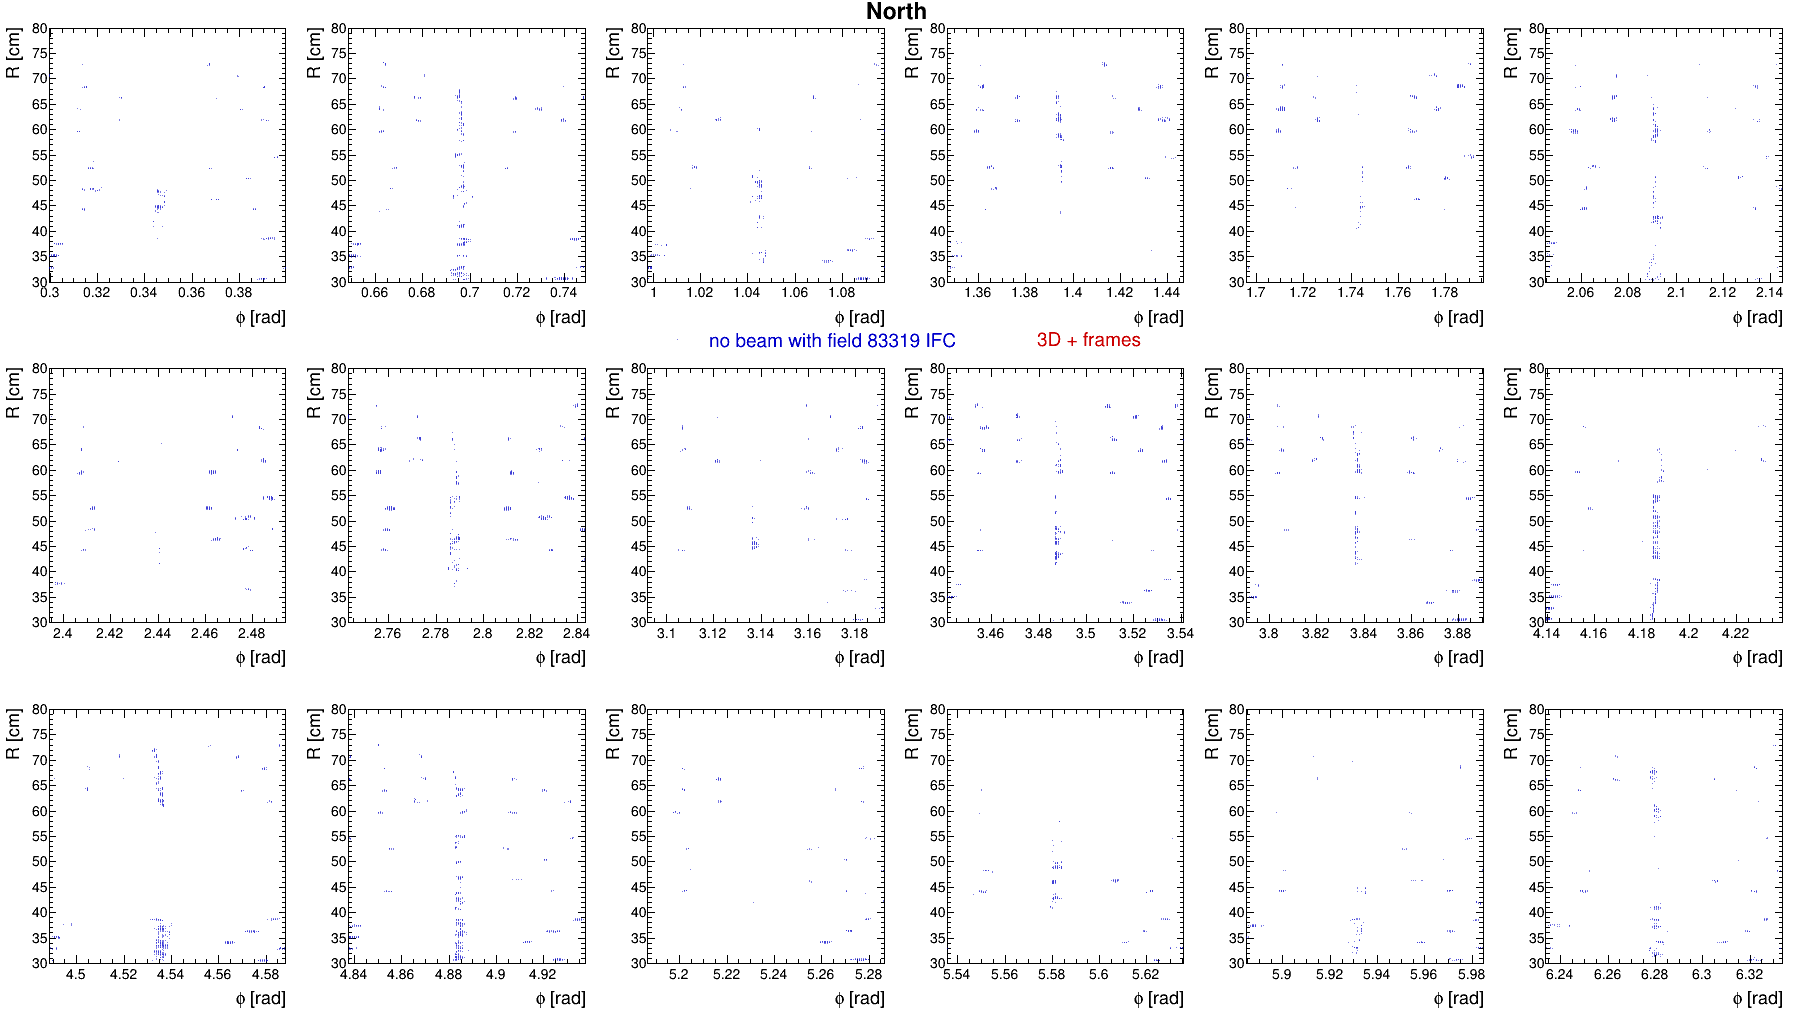

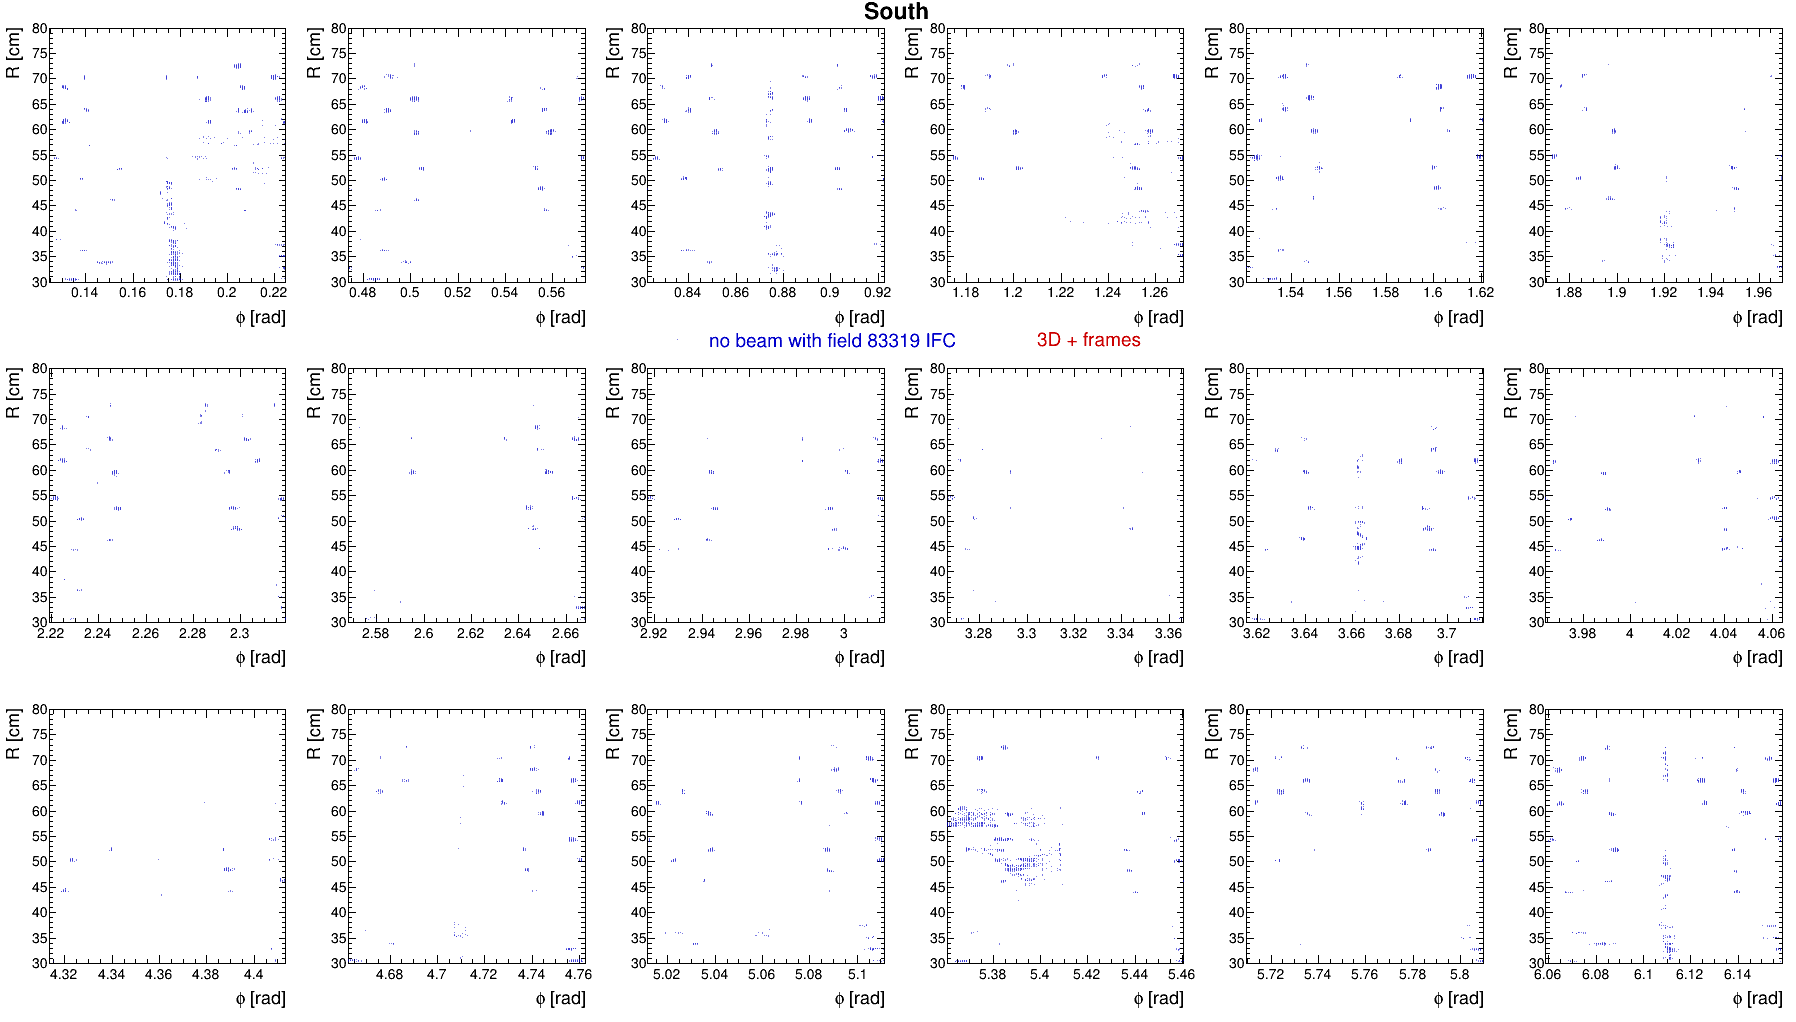

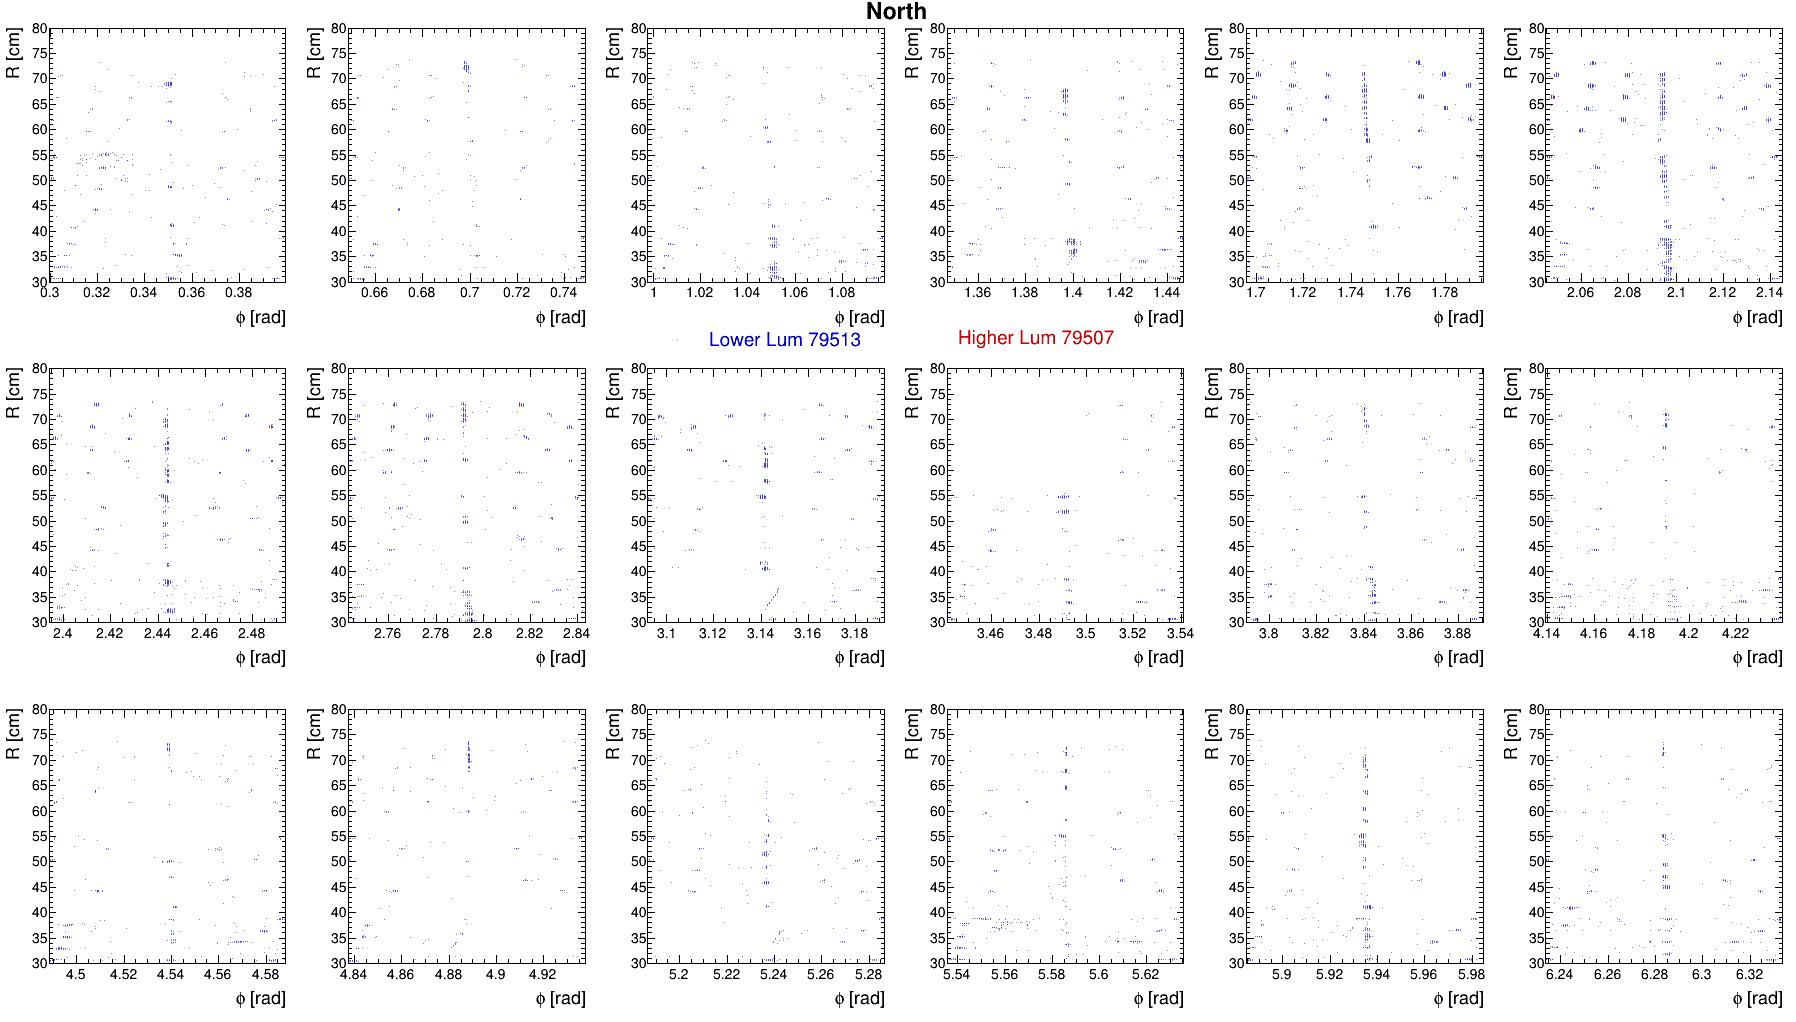

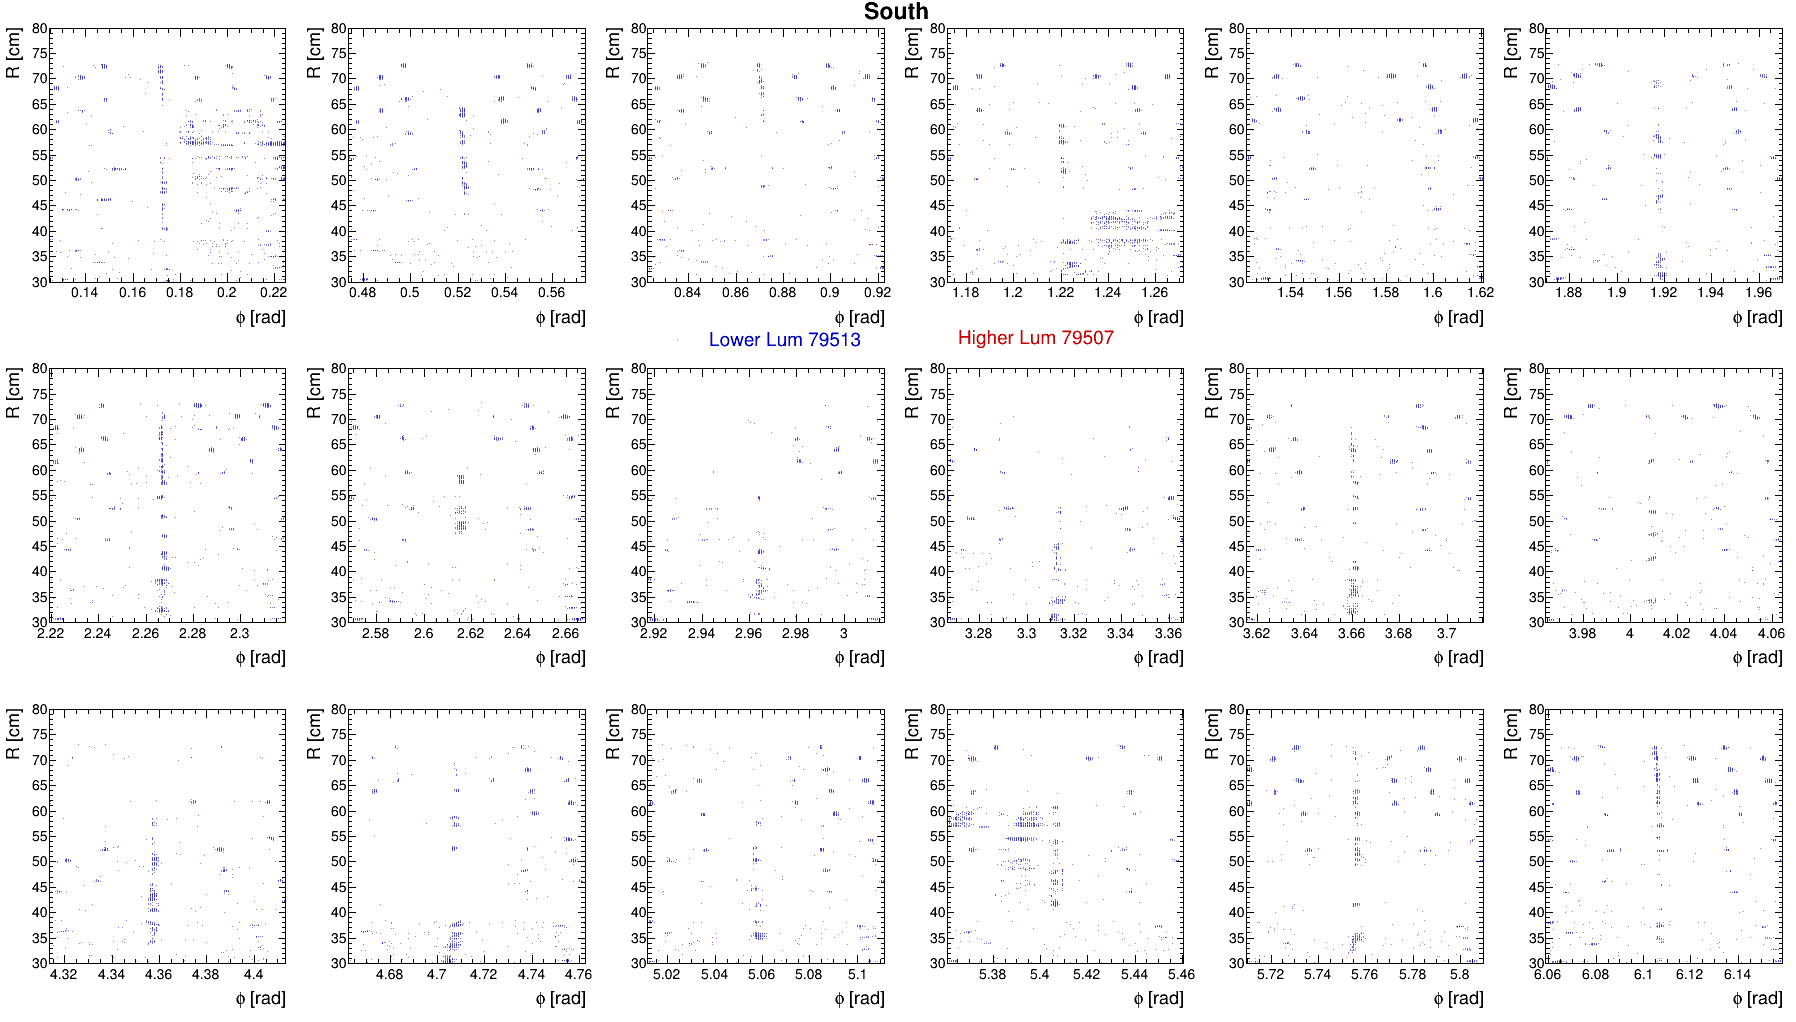

In [ ]:
#compare_sector_windows(["no beam with field 83319 IFC", "3D + frames"], side="North")
#compare_sector_windows(["no beam with field 83319 IFC", "3D + frames"], side="South")
#compare_sector_windows(["Lower Lum 79513", "Higher Lum 79507"], side="North")
#compare_sector_windows(["Lower Lum 79513", "Higher Lum 79507"], side="South")
#compare_sector_windows(["Higher Lum", "3D + frames"], side="North")
#compare_sector_windows(["Higher Lum", "3D + frames"], side="South")
#compare_sector_windows(["no beam no field", "no beam with field 75073"], side="North")
#compare_sector_windows(["no beam no field", "no beam with field 75073"], side="South")
#compare_sector_windows(["Static 2D", "3D + frames"], side="North")
#compare_sector_windows(["Static 2D", "3D + frames"], side="South")
#compare_sector_windows(["no beam no field 78242 IFC", "no beam with field 83319 IFC"], side="North")
#compare_sector_windows(["no beam no field 78242 IFC", "no beam with field 83319 IFC"], side="South")
#compare_sector_windows(["no beam with field 75073", "no beam with field 83319 IFC"], side="North")
#compare_sector_windows(["no beam with field 75073", "no beam with field 83319 IFC"], side="South")

## Batch-produce plots for all configured files

In [ ]:
def make_all_single_file_plots(labels=None, kind="garfield",
                               make_phi_r=True, make_xy=True,
                               make_raw_vs_garfield=False):
    if labels is None:
        labels = list(FILE_CONFIGS.keys())

    made = []
    for label in labels:
        filename = FILE_CONFIGS[label]
        if not filename.exists():
            print(f"Skipping missing file: {label} -> {filename}")
            continue

        print("Plotting:", label)

        if make_phi_r:
            made.append(plot_single_phi_r(label, kind=kind))
        if make_xy:
            made.append(plot_single_xy(label, kind=kind))
        if make_raw_vs_garfield:
            made.append(compare_raw_garfield_xy(label))
            made.append(compare_raw_garfield_phi_r(label))

    return made

# Uncomment:
#all_canvases = make_all_single_file_plots(
#    make_phi_r=True,
#    make_xy=True,
#    make_raw_vs_garfield=True,
#)

## Recommended comparison plots

In [ ]:
#comparison_labels = [
#    "Zero field false",
#    "Static 2D",
#    "3D",
#    "3D + frames",
#]
#
#comparison_labels = [
#    x for x in comparison_labels
#    if x in FILE_CONFIGS and FILE_CONFIGS[x].exists()
#]
#
#print("Using:", comparison_labels)

# Uncomment:
#
#compare_xy(
#    comparison_labels,
#    output_name="79513_correction_progression_xy",
#)

#compare_phi_r(
#    comparison_labels,
#    output_name="79513_correction_progression_phiR",
#)

In [ ]:
# Later, after adding reference files:
#
#reference_comparison = [
#    "Field off + no beam",
#    "Zero field false",
#    "Static 2D",
#    "3D",
#    "3D + frames",
#]

#compare_xy(
#    reference_comparison,
#    output_name="79513_vs_fieldoff_reference_xy",
#)
#
#compare_phi_r(
#    reference_comparison,
#    output_name="79513_vs_fieldoff_reference_phiR",
#)

## Occupancy sanity check

In [ ]:
def occupancy_summary(labels=None, kind="garfield"):
    if labels is None:
        labels = list(FILE_CONFIGS.keys())

    rows = []
    for label in labels:
        filename = FILE_CONFIGS[label]
        if not filename.exists():
            continue
        for side in ["South","North"]:
            h = get_laser_hist(filename, side=side, kind=kind)
            g = hist_to_phi_r_graph(h)
            rows.append((label,side,int(g.GetN())))

    print(f"{'Configuration':28s} {'Side':8s} {'Occupied points':>16s}")
    print("-"*56)
    for label,side,n in rows:
        print(f"{label:28s} {side:8s} {n:16d}")

    return rows

occupancy_summary()

Configuration                Side      Occupied points
--------------------------------------------------------
no beam no field 78242 IFC   South              143638
no beam no field 78242 IFC   North              110420
no beam with field 83319 IFC South               36741
no beam with field 83319 IFC North               22368
no beam with field 75073     South               48604
no beam with field 75073     North               27924
Static 2D                    South               37457
Static 2D                    North               20479
3D                           South               37470
3D                           North               20494
3D + frames                  South               48880
3D + frames                  North               27458
Lower Lum                    South               37916
Lower Lum                    North               20386


[('no beam no field 78242 IFC', 'South', 143638),
 ('no beam no field 78242 IFC', 'North', 110420),
 ('no beam with field 83319 IFC', 'South', 36741),
 ('no beam with field 83319 IFC', 'North', 22368),
 ('no beam with field 75073', 'South', 48604),
 ('no beam with field 75073', 'North', 27924),
 ('Static 2D', 'South', 37457),
 ('Static 2D', 'North', 20479),
 ('3D', 'South', 37470),
 ('3D', 'North', 20494),
 ('3D + frames', 'South', 48880),
 ('3D + frames', 'North', 27458),
 ('Lower Lum', 'South', 37916),
 ('Lower Lum', 'North', 20386)]

## Next quantitative step

After the visual comparison, add stripe-to-reference residuals against the field-off/no-beam pattern:

\[
\Delta R(\phi,R), \qquad R\,\Delta\phi(\phi,R)
\]

and compare RMS / median-absolute residuals for each correction configuration, separately for South/North and eventually R1/R2/R3.